In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from IPython.display import display, HTML
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings("ignore")

In [2]:
fam = pd.read_csv('datasets/Family Income and Expenditure.csv')

In [3]:
fam

,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,...,1,1,0,0,0,2,1,0,0,1
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,...,0,1,0,0,0,3,1,0,0,2
2,82785,CAR,61609,Wage/Salaries,1,34182,32001,7783,2590,1730,...,0,0,0,0,0,0,0,0,0,0
3,107589,CAR,78189,Wage/Salaries,0,34030,28659,10914,10812,690,...,0,0,0,0,0,1,0,0,0,0
4,189322,CAR,94625,Wage/Salaries,0,34820,30167,18391,11309,1395,...,1,0,0,0,0,3,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41539,119773,XII - SOCCSKSARGEN,44875,Enterpreneurial Activities,1,23675,21542,1476,6120,1632,...,0,0,0,0,0,1,0,0,0,0
41540,137320,XII - SOCCSKSARGEN,31157,Enterpreneurial Activities,1,2691,1273,1886,4386,1840,...,0,0,0,0,0,3,0,0,0,0
41541,133171,XII - SOCCSKSARGEN,45882,Enterpreneurial Activities,2,28646,27339,480,4796,1232,...,0,0,0,0,0,1,0,0,0,0
41542,129500,XII - SOCCSKSARGEN,81416,Enterpreneurial Activities,1,29996,26655,2359,17730,2923,...,0,0,0,0,0,2,0,0,0,0


<h1>Insight 1: The Distribution of Total Household Income</h1>

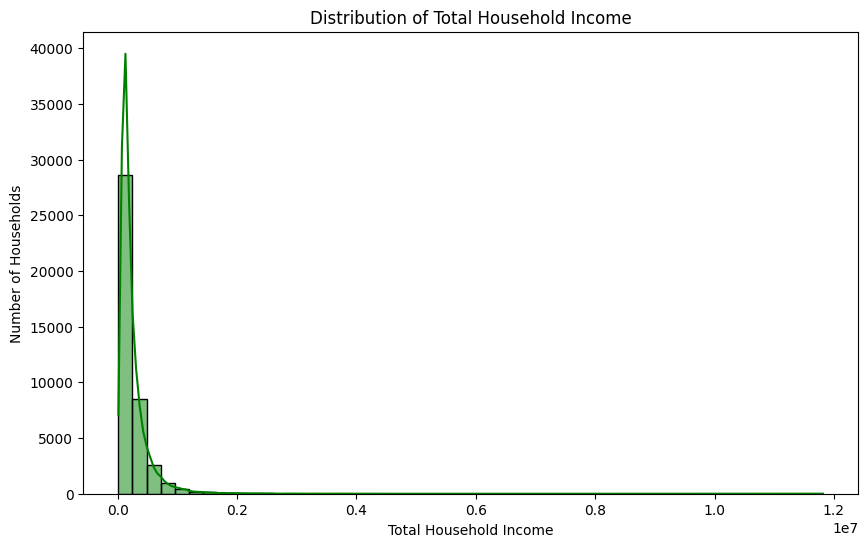

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(fam['Total Household Income'], bins=50, kde=True, color='green')
plt.title('Distribution of Total Household Income')
plt.xlabel('Total Household Income')
plt.ylabel('Number of Households')
plt.show()


Most households in the dataset have incomes below the average, which indicates a right-skewed distribution. This means that while a few households earn much higher incomes, the majority earn less. These higher-income households raise the overall average, even though most families are in the lower income range. This pattern suggests income inequality, with earnings concentrated more heavily among a smaller group at the top.

<h1> Insight 2: Heatmap of Major Expenditures and Income

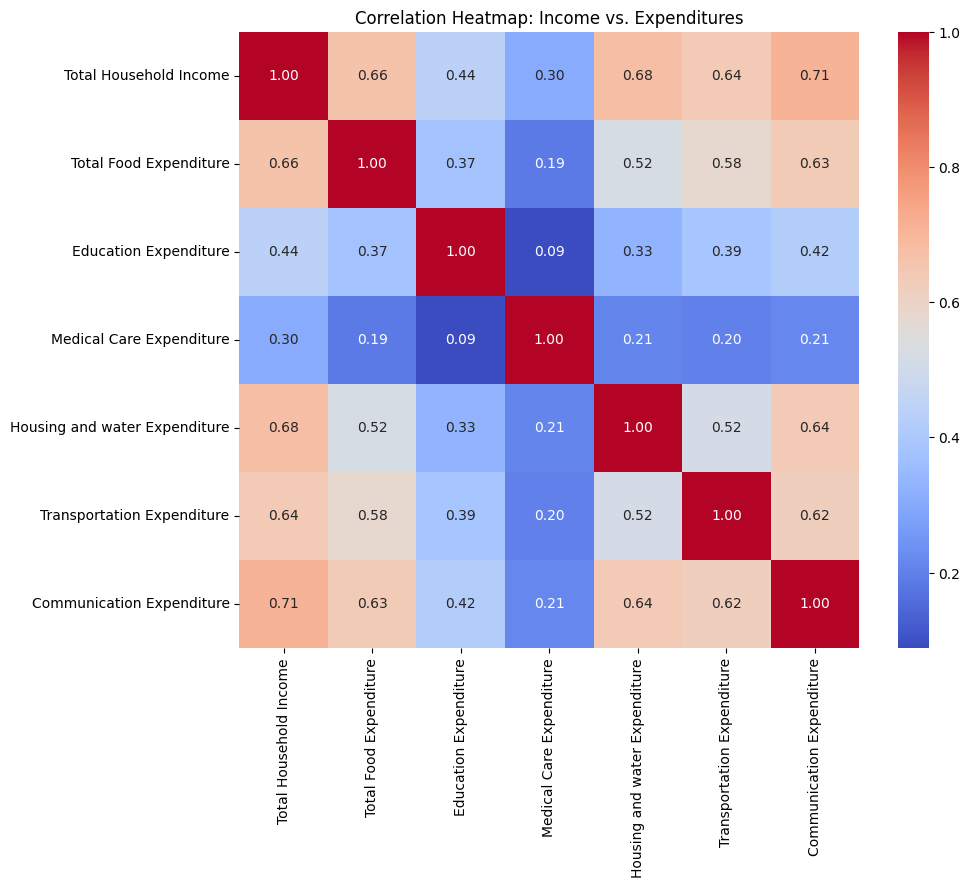

In [5]:
cols = [
    'Total Household Income',
    'Total Food Expenditure',
    'Education Expenditure',
    'Medical Care Expenditure',
    'Housing and water Expenditure',
    'Transportation Expenditure',
    'Communication Expenditure'
]

plt.figure(figsize=(10, 8))
sns.heatmap(fam[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Income vs. Expenditures')
plt.show()

Helps visualize how different types of expenses relate to income and each other.

<h1>Insight 3: Average Income by Region (Geospatial Style using Bar Color Map)

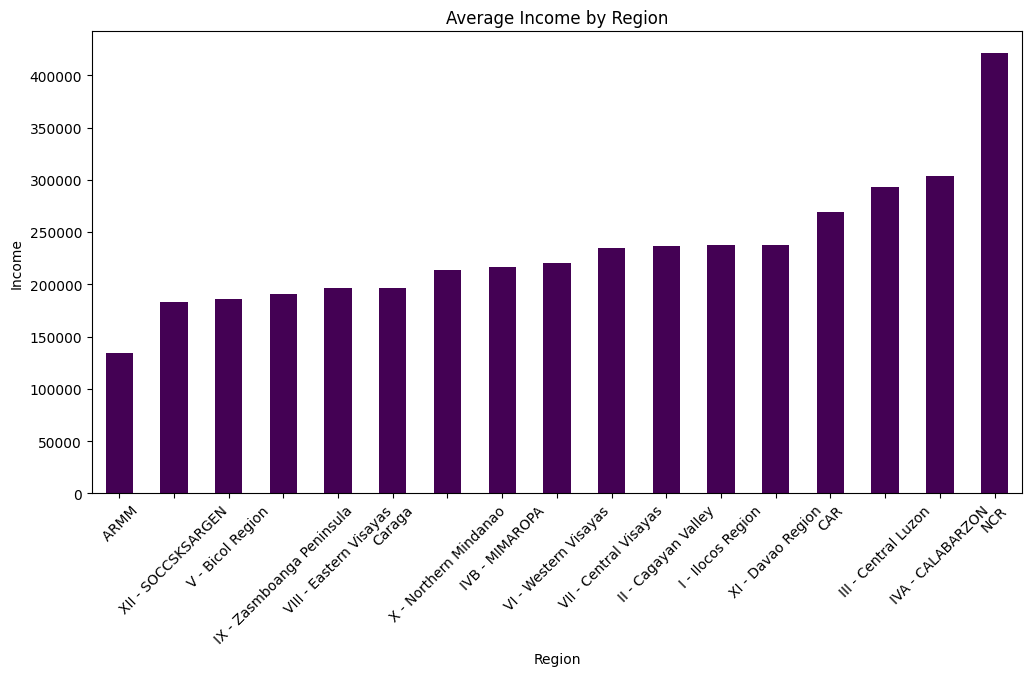

In [6]:
region_income = fam.groupby('Region')['Total Household Income'].mean().sort_values()
plt.figure(figsize=(12, 6))
region_income.plot(kind='bar', cmap='viridis')
plt.title('Average Income by Region')
plt.ylabel('Income')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.show()


Approximates regional income disparity using a color-coded bar chart (geospatial substitute since actual coordinates aren't present).

<h1>  Insight 4: Correlation Between Number of Family Members and Food Expenditure

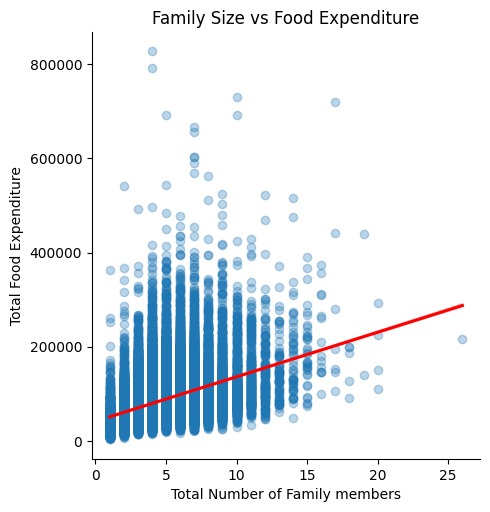

In [7]:
sns.lmplot(
    x='Total Number of Family members',
    y='Total Food Expenditure',
    data=fam,
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)
plt.title('Family Size vs Food Expenditure')
plt.show()


Larger households tend to spend more on food, which is expected since more family members lead to higher overall consumption. As the number of people in a household increases, so does the need for food, resulting in greater total food expenditure. This trend reflects the natural relationship between household size and basic living costs.

<h1>Insight 5: Pairplot of Key Variables

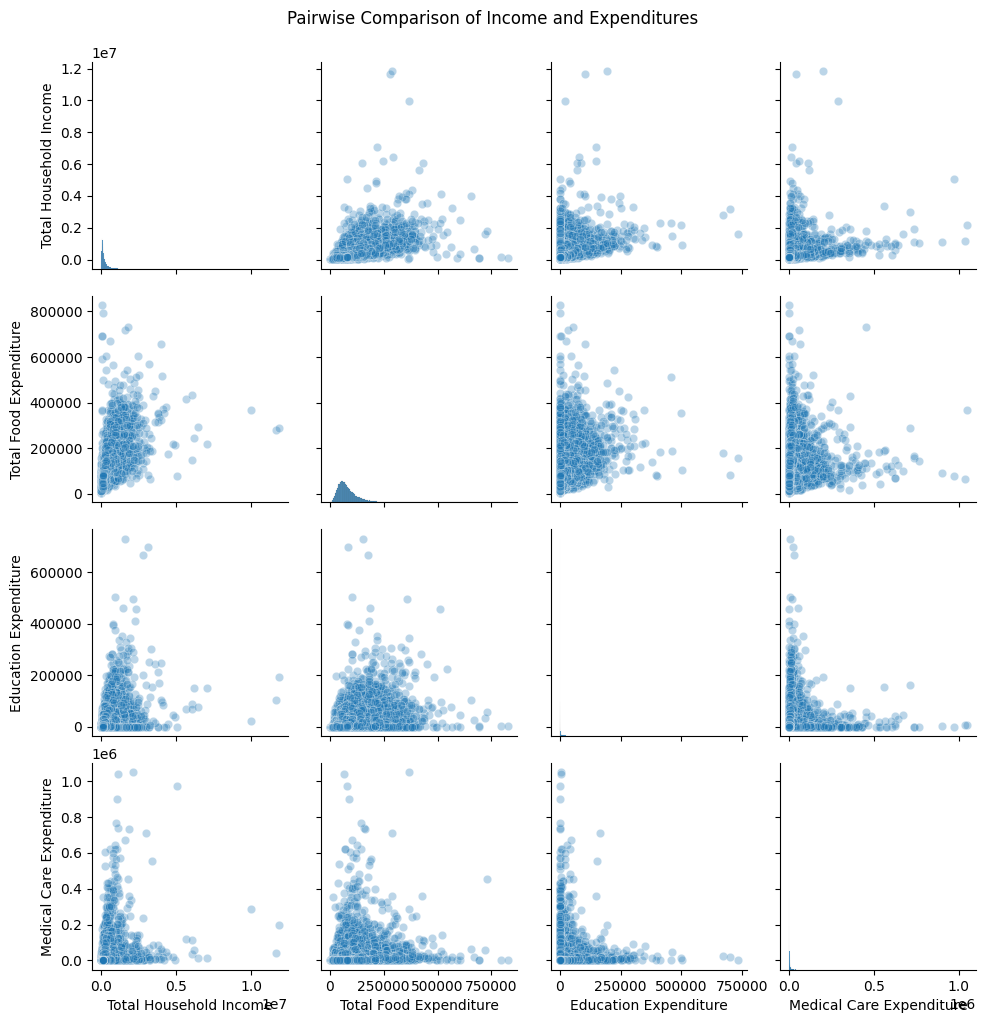

In [8]:
sns.pairplot(
    fam[[
        'Total Household Income',
        'Total Food Expenditure',
        'Education Expenditure',
        'Medical Care Expenditure'
    ]],
    plot_kws={'alpha': 0.3}
)
plt.suptitle("Pairwise Comparison of Income and Expenditures", y=1.02)
plt.show()


Visual patterns emerge when comparing all key features together.

<h1> Insight 6: Correlation Between Education and Medical Expenditure

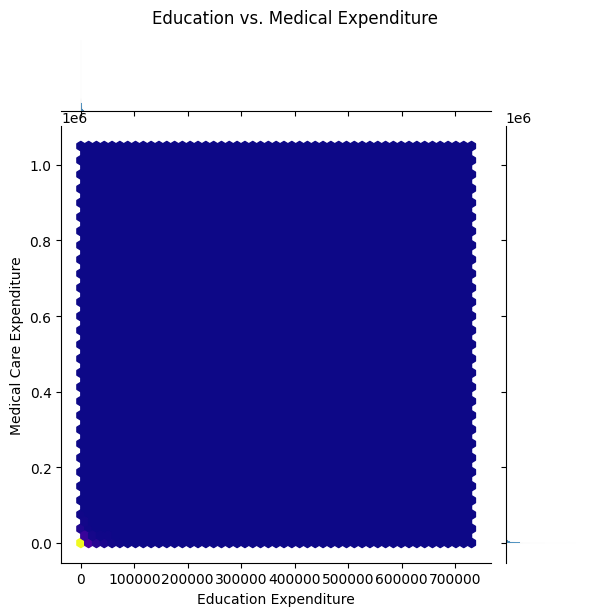

In [9]:
sns.jointplot(
    x='Education Expenditure',
    y='Medical Care Expenditure',
    data=fam,
    kind='hex',
    cmap='plasma'
).fig.suptitle('Education vs. Medical Expenditure', y=1.02)
plt.show()


Families that spend more on education also tend to spend more on healthcare.

<h1>Insight 7: Income vs Education Expenditure

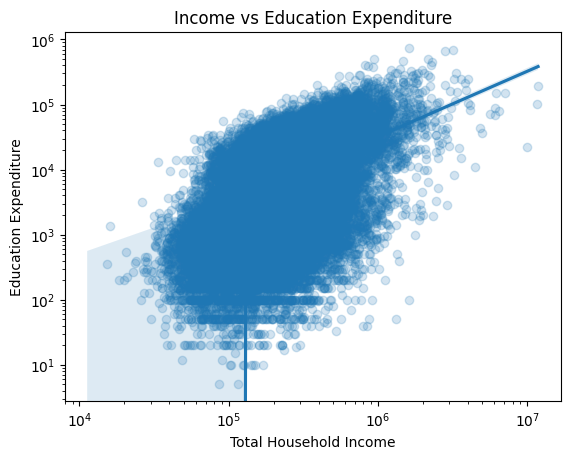

In [10]:
sns.regplot(x='Total Household Income', y='Education Expenditure', data=fam, scatter_kws={'alpha':0.2})
plt.title('Income vs Education Expenditure')
plt.xlabel('Total Household Income')
plt.ylabel('Education Expenditure')
plt.yscale('log')
plt.xscale('log')
plt.show()


Households with higher income levels typically allocate more money toward education expenses. This trend suggests that as a family's financial capacity increases, they are more likely to invest in schooling, tuition, and other educational needs. It reflects a common pattern where wealthier families prioritize education as part of long-term development and opportunities for their members.

<h1> Insight 8: Food Expenditure Ratio

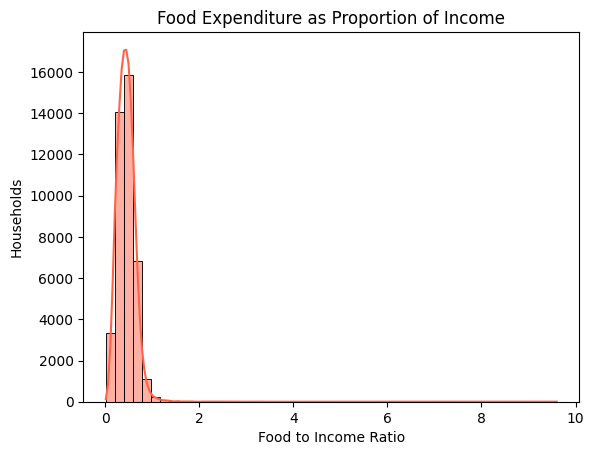

In [11]:
fam['Food_Income_Ratio'] = fam['Total Food Expenditure'] / fam['Total Household Income']
sns.histplot(fam['Food_Income_Ratio'], bins=50, kde=True, color='tomato')
plt.title('Food Expenditure as Proportion of Income')
plt.xlabel('Food to Income Ratio')
plt.ylabel('Households')
plt.show()


Food consumes a larger income share in low-income families.

<h1>Insight 9: Transportation Correlation Heatmap

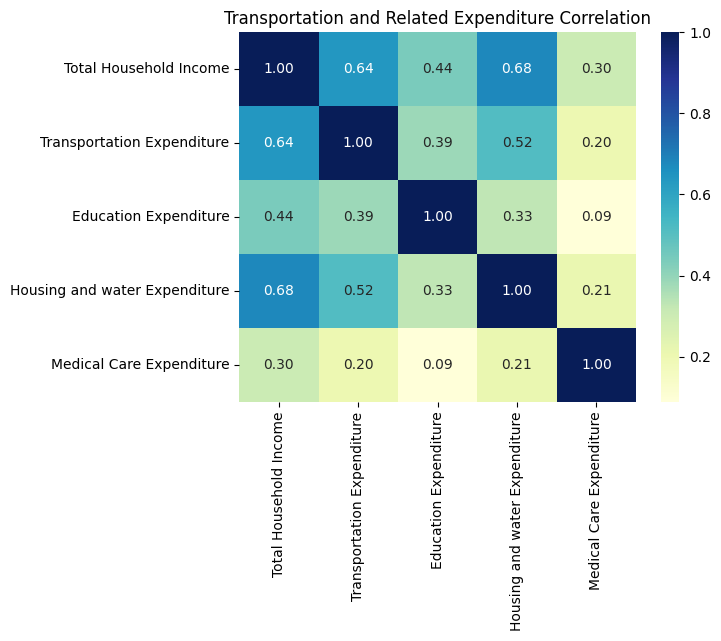

In [12]:
cols = [
    'Total Household Income', 'Transportation Expenditure', 'Education Expenditure',
    'Housing and water Expenditure', 'Medical Care Expenditure'
]
sns.heatmap(fam[cols].corr(), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Transportation and Related Expenditure Correlation')
plt.show()


Transportation costs moderately correlate with other key expenses.

<h1>Insight 10: Education vs Housing Expense

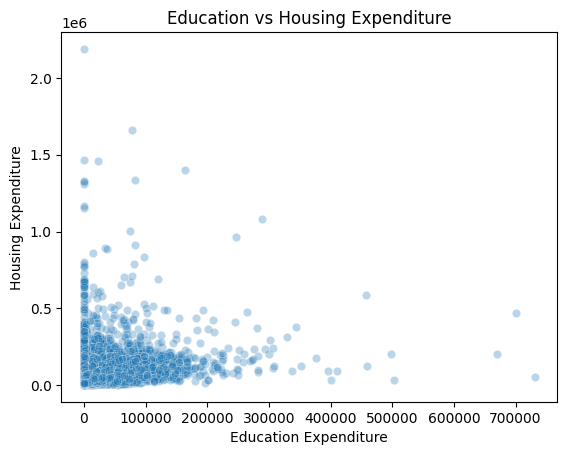

In [13]:
sns.scatterplot(x='Education Expenditure', y='Housing and water Expenditure', data=fam, alpha=0.3)
plt.title('Education vs Housing Expenditure')
plt.xlabel('Education Expenditure')
plt.ylabel('Housing Expenditure')
plt.show()

Households investing in education often spend more on housing

# Insight 11: Communication by Income Quartile



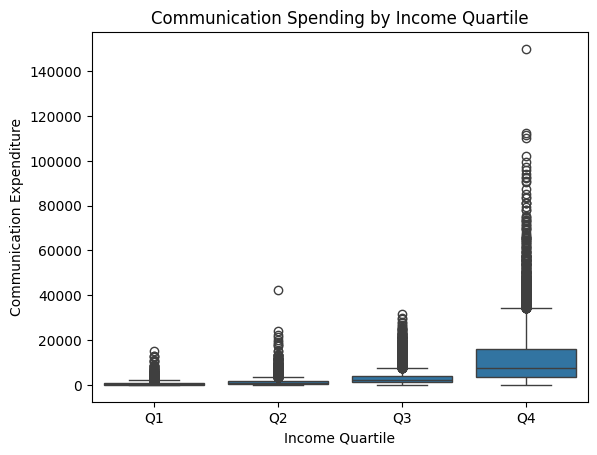

In [14]:
fam['Income Quartile'] = pd.qcut(fam['Total Household Income'], 4, labels=['Q1','Q2','Q3','Q4'])
sns.boxplot(x='Income Quartile', y='Communication Expenditure', data=fam)
plt.title('Communication Spending by Income Quartile')
plt.show()

Higher income groups spend more on communication.

#  Insight 12: Gadget Ownership and Income



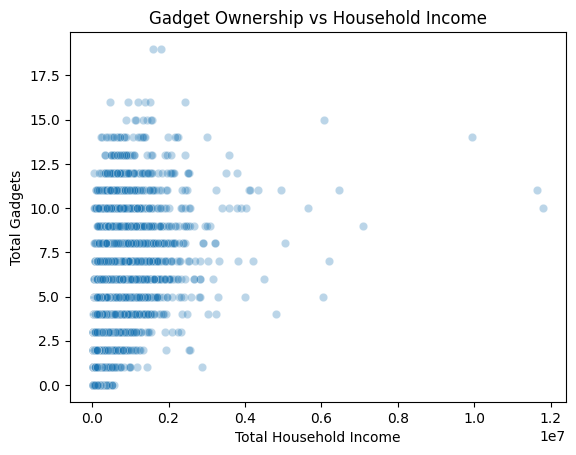

In [15]:
fam['Total Gadgets'] = fam['Number of Television'] + fam['Number of CD/VCD/DVD'] + fam['Number of Cellular phone']
sns.scatterplot(x='Total Household Income', y='Total Gadgets', data=fam, alpha=0.3)
plt.title('Gadget Ownership vs Household Income')
plt.show()

Gadget ownership increases with income.

# Insight 13: Main Source of Income by Region

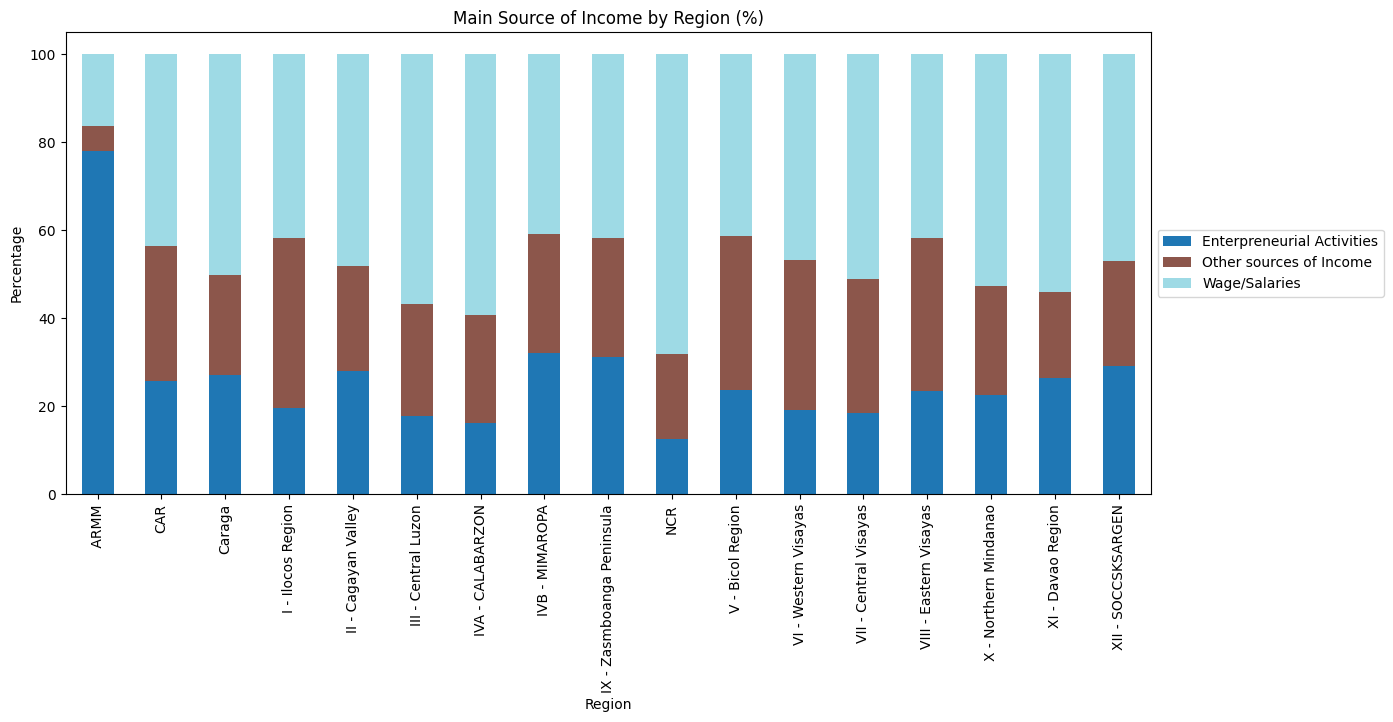

In [16]:
income_source = pd.crosstab(fam['Region'], fam['Main Source of Income'], normalize='index') * 100
income_source.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20')
plt.title('Main Source of Income by Region (%)')
plt.ylabel('Percentage')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

Income sources vary greatly across regions.

# Insight 14:  Income by Household Head Gender

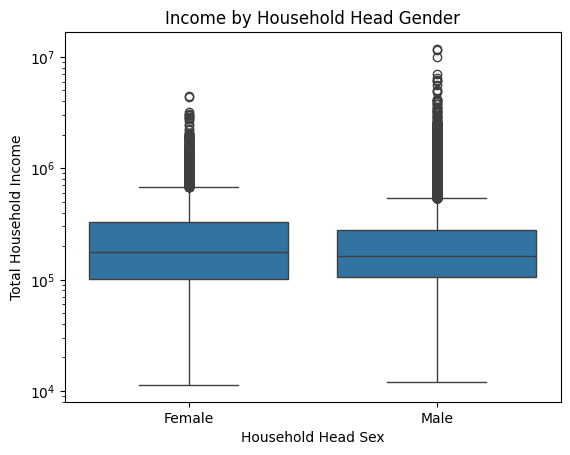

In [17]:
sns.boxplot(x='Household Head Sex', y='Total Household Income', data=fam)
plt.title('Income by Household Head Gender')
plt.yscale('log')
plt.show()

Male-headed households tend to have slightly higher income.



#  Insight 15: Motorcycle Ownership and Transport Cost

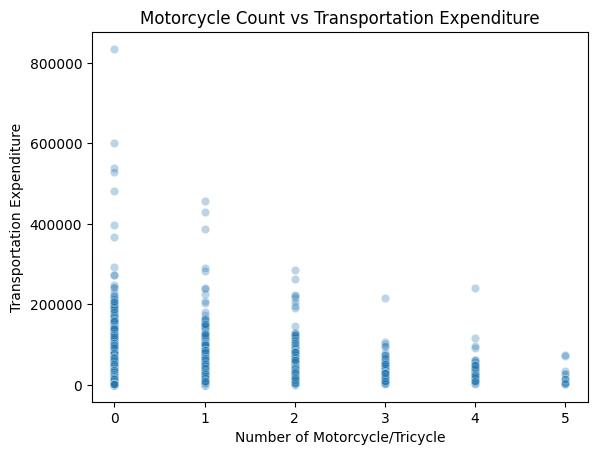

In [18]:
sns.scatterplot(x='Number of Motorcycle/Tricycle', y='Transportation Expenditure', data=fam, alpha=0.3)
plt.title('Motorcycle Count vs Transportation Expenditure')
plt.show()

Motorcycle owners spend more on transportation-related costs.



# Insight16: Income by Marital Status

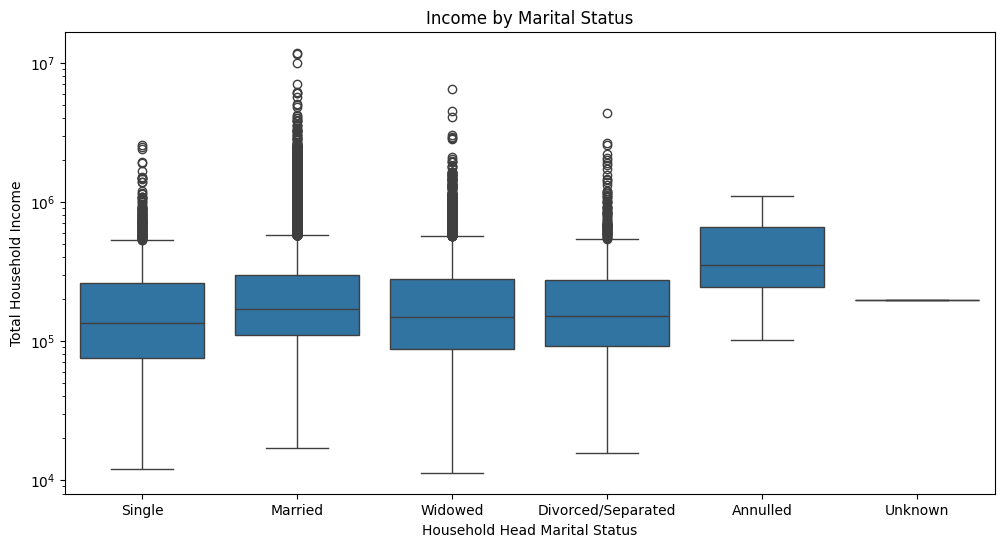

In [19]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Household Head Marital Status', y='Total Household Income', data=fam)
plt.title('Income by Marital Status')
plt.yscale('log')
plt.show()

The data indicates that household heads who are married generally have higher incomes. This may be due to combined earnings from both partners or greater financial stability often associated with married life. It suggests that marital status can play a role in influencing household income levels.

#  Insight 17: Agricultural Households’ Income

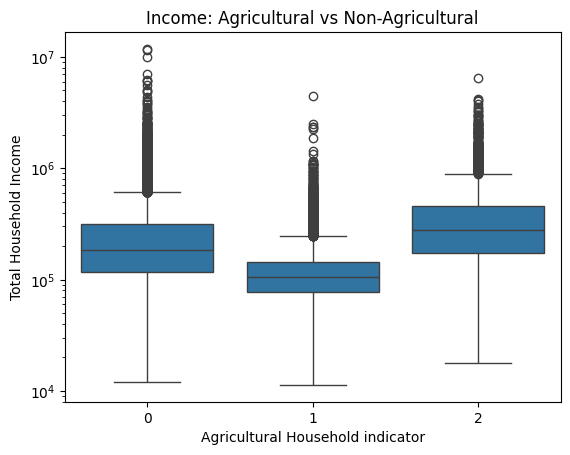

In [20]:
sns.boxplot(x='Agricultural Household indicator', y='Total Household Income', data=fam)
plt.title('Income: Agricultural vs Non-Agricultural')
plt.yscale('log')
plt.show()

Agricultural households generally earn less than non-agricultural ones.

# Insight 18: Source of Income Distribution

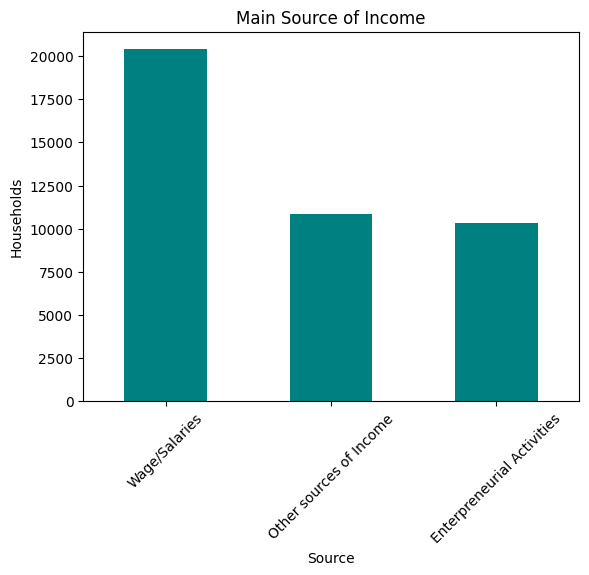

In [21]:
fam['Main Source of Income'].value_counts().plot(kind='bar', color='teal')
plt.title('Main Source of Income')
plt.xlabel('Source')
plt.ylabel('Households')
plt.xticks(rotation=45)
plt.show()

The majority of households in the dataset report wages or salaries as their main source of income. This indicates that formal employment is the primary means of earning for most families, reflecting a dependence on regular jobs rather than self-employment, business, or agricultural activities.

#  Insight 19: Education Expenditure by Region

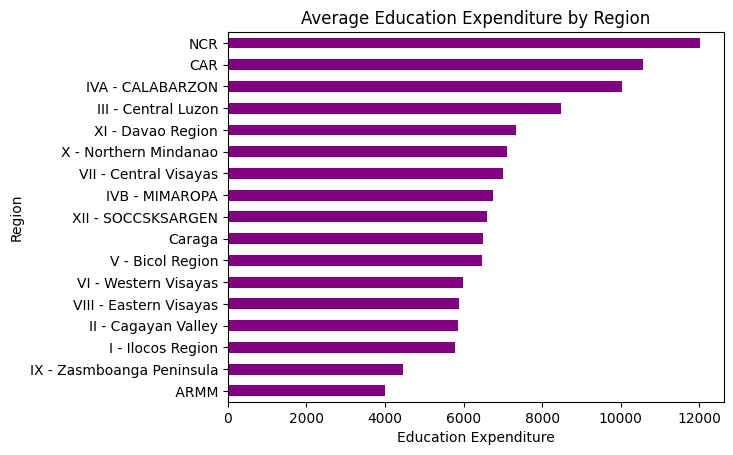

In [22]:
region_edu = fam.groupby('Region')['Education Expenditure'].mean().sort_values()
region_edu.plot(kind='barh', color='purple')
plt.title('Average Education Expenditure by Region')
plt.xlabel('Education Expenditure')
plt.ylabel('Region')
plt.show()

 Urbanized regions tend to spend more on education.

# Insight 20: Housing Expenditure vs. Income

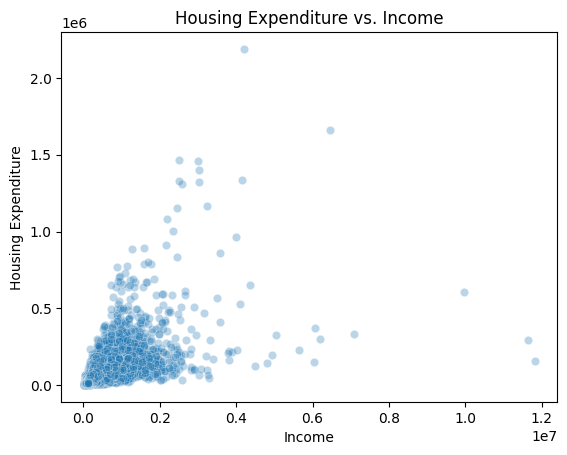

In [23]:
sns.scatterplot(data=fam, x='Total Household Income', y='Housing and water Expenditure', alpha=0.3)
plt.title('Housing Expenditure vs. Income')
plt.xlabel('Income')
plt.ylabel('Housing Expenditure')
plt.show()

Households with higher income tend to spend more on housing.